In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
lstm_pred = pd.read_csv("../reports/lstm_predictions.csv")
gru_pred = pd.read_csv("../reports/gru_predictions.csv")

print("LSTM predictions:", lstm_pred.shape)
print("GRU predictions :", gru_pred.shape)

print("\nLSTM columns:")
print(lstm_pred.columns.tolist())

print("\nGRU columns:")
print(gru_pred.columns.tolist())

LSTM predictions: (307058, 2)
GRU predictions : (307058, 2)

LSTM columns:
['Actual', 'Predicted']

GRU columns:
['Actual', 'Predicted']


In [3]:
print(
    "Same number of test predictions:",
    len(lstm_pred) == len(gru_pred)
)

print(
    "Same actual test values:",
    np.allclose(
        lstm_pred["Actual"].values,
        gru_pred["Actual"].values
    )
)

Same number of test predictions: True
Same actual test values: True


In [4]:
verification = pd.DataFrame({
    "Check": [
        "LSTM and GRU prediction count matches",
        "LSTM and GRU actual test values match",
        "Expected test predictions",
        "Actual LSTM predictions",
        "Actual GRU predictions"
    ],
    "Result": [
        len(lstm_pred) == len(gru_pred),
        np.allclose(
            lstm_pred["Actual"].values,
            gru_pred["Actual"].values
        ),
        307118 - 60,
        len(lstm_pred),
        len(gru_pred)
    ]
})

verification

,Check,Result
0,LSTM and GRU prediction count matches,True
1,LSTM and GRU actual test values match,True
2,Expected test predictions,307058
3,Actual LSTM predictions,307058
4,Actual GRU predictions,307058


In [ ]:
## Data Leakage Verification

The LSTM and GRU preprocessing pipelines were independently reviewed.

Both models used the same chronological 70% / 15% / 15% Train,
Validation, and Test split.

For both pipelines, MinMaxScaler was fitted exclusively on the
training partition using `fit_transform()`.

## Overfitting Analysis

Training and validation loss curves were reviewed for both LSTM and GRU models.

### LSTM

The LSTM training

In [9]:
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # Avoid division by zero when calculating MAPE
    nonzero_mask = actual != 0

    mape = np.mean(
        np.abs(
            (actual[nonzero_mask] - predicted[nonzero_mask])
            / actual[nonzero_mask]
        )
    ) * 100

    r2 = r2_score(actual, predicted)

    return mae, rmse, mape, r2


# LSTM metrics
lstm_mae, lstm_rmse, lstm_mape, lstm_r2 = calculate_metrics(
    lstm_pred["Actual"].values,
    lstm_pred["Predicted"].values
)

# GRU metrics
gru_mae, gru_rmse, gru_mape, gru_r2 = calculate_metrics(
    gru_pred["Actual"].values,
    gru_pred["Predicted"].values
)


comparison_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [lstm_mae, gru_mae],
    "RMSE": [lstm_rmse, gru_rmse],
    "MAPE (%)": [lstm_mape, gru_mape],
    "R2": [lstm_r2, gru_r2]
})

comparison_df

,Model,MAE,RMSE,MAPE (%),R2
0,LSTM,0.008237,0.018954,16.642518,0.940958
1,GRU,0.008761,0.019216,20.116946,0.939318


### Model Artifact Verification

The exported LSTM and GRU model artifacts and prediction files were
reviewed as part of the final evaluation process.

The tuned LSTM and tuned GRU configurations were successfully trained
and evaluated during their respective model-development stages.
However, only the baseline model objects were exported as `.keras`
files.

The stored LSTM and GRU prediction CSV files were also independently
evaluated, and the calculated metrics reproduced the baseline-model
results.

Therefore:

- Tuned LSTM and GRU experiments were completed and evaluated.
- Baseline LSTM and GRU models were exported.
- Baseline prediction outputs were exported.
- Tuned model artifacts and tuned prediction outputs were not exported.

The final selected deep-learning configuration must therefore be
exported with its corresponding prediction outputs before handover to
downstream groups.

## Model Experiment Management

Four deep-learning experiments were reviewed:

1. Baseline LSTM
2. Tuned LSTM
3. Baseline GRU
4. Tuned GRU

All experiments used the same target variable, chronological data split,
60-step sequence window, batch size of 64, Adam optimizer, and three
training epochs. The main tuning changes were the number of recurrent
units and dropout rate.

In [10]:
experiment_df = pd.DataFrame({
    "Experiment": [
        "Baseline LSTM",
        "Tuned LSTM",
        "Baseline GRU",
        "Tuned GRU"
    ],
    "Model": [
        "LSTM",
        "LSTM",
        "GRU",
        "GRU"
    ],
    "Units": [
        64,
        128,
        64,
        128
    ],
    "Dropout": [
        0.20,
        0.30,
        0.20,
        0.30
    ],
    "Window_Size": [
        60,
        60,
        60,
        60
    ],
    "Batch_Size": [
        64,
        64,
        64,
        64
    ],
    "Epochs": [
        3,
        3,
        3,
        3
    ],
    "Optimizer": [
        "Adam",
        "Adam",
        "Adam",
        "Adam"
    ],
    "MAE": [
        0.008237,
        0.007717,
        0.008761,
        0.008001
    ],
    "RMSE": [
        0.018954,
        0.018971,
        0.019216,
        0.018833
    ],
    "MAPE": [
        16.64,
        13.91,
        20.12,
        16.25
    ],
    "R2": [
        0.940958,
        0.940856,
        0.939318,
        0.941713
    ]
})

experiment_df

,Experiment,Model,Units,Dropout,Window_Size,Batch_Size,Epochs,Optimizer,MAE,RMSE,MAPE,R2
0,Baseline LSTM,LSTM,64,0.2,60,64,3,Adam,0.008237,0.018954,16.64,0.940958
1,Tuned LSTM,LSTM,128,0.3,60,64,3,Adam,0.007717,0.018971,13.91,0.940856
2,Baseline GRU,GRU,64,0.2,60,64,3,Adam,0.008761,0.019216,20.12,0.939318
3,Tuned GRU,GRU,128,0.3,60,64,3,Adam,0.008001,0.018833,16.25,0.941713


In [11]:
best_candidates = experiment_df[
    experiment_df["Experiment"].isin(
        ["Tuned LSTM", "Tuned GRU"]
    )
].copy()

best_candidates

,Experiment,Model,Units,Dropout,Window_Size,Batch_Size,Epochs,Optimizer,MAE,RMSE,MAPE,R2
1,Tuned LSTM,LSTM,128,0.3,60,64,3,Adam,0.007717,0.018971,13.91,0.940856
3,Tuned GRU,GRU,128,0.3,60,64,3,Adam,0.008001,0.018833,16.25,0.941713


In [12]:
metric_winners = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Better_Direction": ["Lower", "Lower", "Lower", "Higher"],
    "LSTM": [0.007717, 0.018971, 13.91, 0.940856],
    "GRU": [0.008001, 0.018833, 16.25, 0.941713],
    "Winner": ["LSTM", "GRU", "LSTM", "GRU"]
})

metric_winners

,Metric,Better_Direction,LSTM,GRU,Winner
0,MAE,Lower,0.007717,0.008001,LSTM
1,RMSE,Lower,0.018971,0.018833,GRU
2,MAPE,Lower,13.910000,16.250000,LSTM
3,R2,Higher,0.940856,0.941713,GRU


## Error and Residual Analysis

Residual analysis was performed using the available exported prediction
files.

Independent metric verification previously confirmed that these prediction
files correspond to the baseline LSTM and baseline GRU configurations,
rather than the tuned configurations.

Therefore, the following residual analysis is interpreted as diagnostic
analysis of the exported baseline model predictions and is not presented
as residual analysis of the tuned models.

Residual is defined as:

Residual = Actual - Predicted

A positive residual indicates underprediction, while a negative residual
indicates overprediction.

In [13]:
# Create residuals from the available exported baseline predictions

lstm_residuals = (
    lstm_pred["Actual"].values -
    lstm_pred["Predicted"].values
)

gru_residuals = (
    gru_pred["Actual"].values -
    gru_pred["Predicted"].values
)

# Absolute errors
lstm_abs_errors = np.abs(lstm_residuals)
gru_abs_errors = np.abs(gru_residuals)

residual_stats = pd.DataFrame({
    "Model": ["Baseline LSTM", "Baseline GRU"],

    "Mean_Residual": [
        np.mean(lstm_residuals),
        np.mean(gru_residuals)
    ],

    "Median_Residual": [
        np.median(lstm_residuals),
        np.median(gru_residuals)
    ],

    "Residual_Std": [
        np.std(lstm_residuals),
        np.std(gru_residuals)
    ],

    "Mean_Absolute_Error": [
        np.mean(lstm_abs_errors),
        np.mean(gru_abs_errors)
    ],

    "Max_Absolute_Error": [
        np.max(lstm_abs_errors),
        np.max(gru_abs_errors)
    ]
})

residual_stats

,Model,Mean_Residual,Median_Residual,Residual_Std,Mean_Absolute_Error,Max_Absolute_Error
0,Baseline LSTM,-0.002406,-0.002430,0.018801,0.008237,0.334848
1,Baseline GRU,-0.001519,-0.002221,0.019156,0.008761,0.364879


### Residual Analysis Findings

Residuals were defined as `Actual - Predicted`.

Both exported baseline models produced slightly negative mean residuals,
indicating a small overall tendency toward overprediction.

The Baseline GRU achieved a mean residual closer to zero, suggesting
slightly lower systematic prediction bias. However, the Baseline LSTM
produced a lower residual standard deviation, lower mean absolute error,
and lower maximum absolute error.

Therefore, the exported Baseline LSTM predictions demonstrated slightly
more stable and lower-magnitude errors overall, while the Baseline GRU
showed slightly less average bias.

These findings apply only to the exported baseline prediction artifacts
and are not treated as residual results for the tuned configurations.

In [16]:
actual = lstm_pred["Actual"].values

high_demand_threshold = np.percentile(actual, 90)

actual = lstm_pred["Actual"].values

# Define high demand as the top 10% of actual test demand
high_demand_threshold = np.percentile(actual, 90)

high_demand_mask = actual >= high_demand_threshold

print("90th percentile threshold:", high_demand_threshold)
print("High-demand observations:", high_demand_mask.sum())
print(
    "Percentage of test predictions:",
    high_demand_mask.mean() * 100
)

90th percentile threshold: 0.1739996378779648
High-demand observations: 30736
Percentage of test predictions: 10.00983527542028


In [19]:
# Predictions during high-demand periods
lstm_high_pred = lstm_pred["Predicted"].values[high_demand_mask]
gru_high_pred = gru_pred["Predicted"].values[high_demand_mask]

# Actual values during high-demand periods
actual_high = actual[high_demand_mask]


# Function to calculate high-demand performance metrics
def high_demand_metrics(actual_values, predicted_values):
    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    # Avoid division by zero for MAPE
    nonzero_mask = actual_values != 0

    mape = np.mean(
        np.abs(
            (
                actual_values[nonzero_mask]
                - predicted_values[nonzero_mask]
            )
            / actual_values[nonzero_mask]
        )
    ) * 100

    r2 = r2_score(
        actual_values,
        predicted_values
    )

    return mae, rmse, mape, r2


# Calculate high-demand metrics for LSTM
lstm_high_metrics = high_demand_metrics(
    actual_high,
    lstm_high_pred
)


# Calculate high-demand metrics for GRU
gru_high_metrics = high_demand_metrics(
    actual_high,
    gru_high_pred
)


# Create comparison table
high_demand_df = pd.DataFrame({
    "Model": [
        "Baseline LSTM",
        "Baseline GRU"
    ],
    "MAE": [
        lstm_high_metrics[0],
        gru_high_metrics[0]
    ],
    "RMSE": [
        lstm_high_metrics[1],
        gru_high_metrics[1]
    ],
    "MAPE (%)": [
        lstm_high_metrics[2],
        gru_high_metrics[2]
    ],
    "R2": [
        lstm_high_metrics[3],
        gru_high_metrics[3]
    ]
})


high_demand_df

,Model,MAE,RMSE,MAPE (%),R2
0,Baseline LSTM,0.023774,0.041871,9.241124,0.700754
1,Baseline GRU,0.024702,0.043026,9.575193,0.684022


### High-Demand Performance Findings

High-demand observations were defined as test-set observations at or above
the 90th percentile of actual energy consumption. This produced 30,736
high-demand observations, representing approximately 10% of the available
test predictions.

For the exported baseline prediction artifacts, the Baseline LSTM achieved
lower MAE and MAPE and a higher R² during high-demand periods. The Baseline
GRU achieved a slightly lower RMSE.

The higher high-demand MAE and RMSE values compared with overall test-set
performance indicate that both models experience greater forecasting
difficulty during periods of elevated energy consumption.

Overall, the Baseline LSTM demonstrated stronger high-demand performance
across three of the four reported metrics.

These results apply to the exported baseline prediction artifacts and
should not be interpreted as high-demand results for the tuned LSTM and
GRU configurations.

In [20]:
residual_stats.to_csv(
    "../reports/dl_residual_statistics.csv",
    index=False
)

high_demand_df.to_csv(
    "../reports/dl_high_demand_metrics.csv",
    index=False
)

metric_winners.to_csv(
    "../reports/dl_metric_winners.csv",
    index=False
)

print("Member 3 diagnostic results saved successfully.")

Member 3 diagnostic results saved successfully.


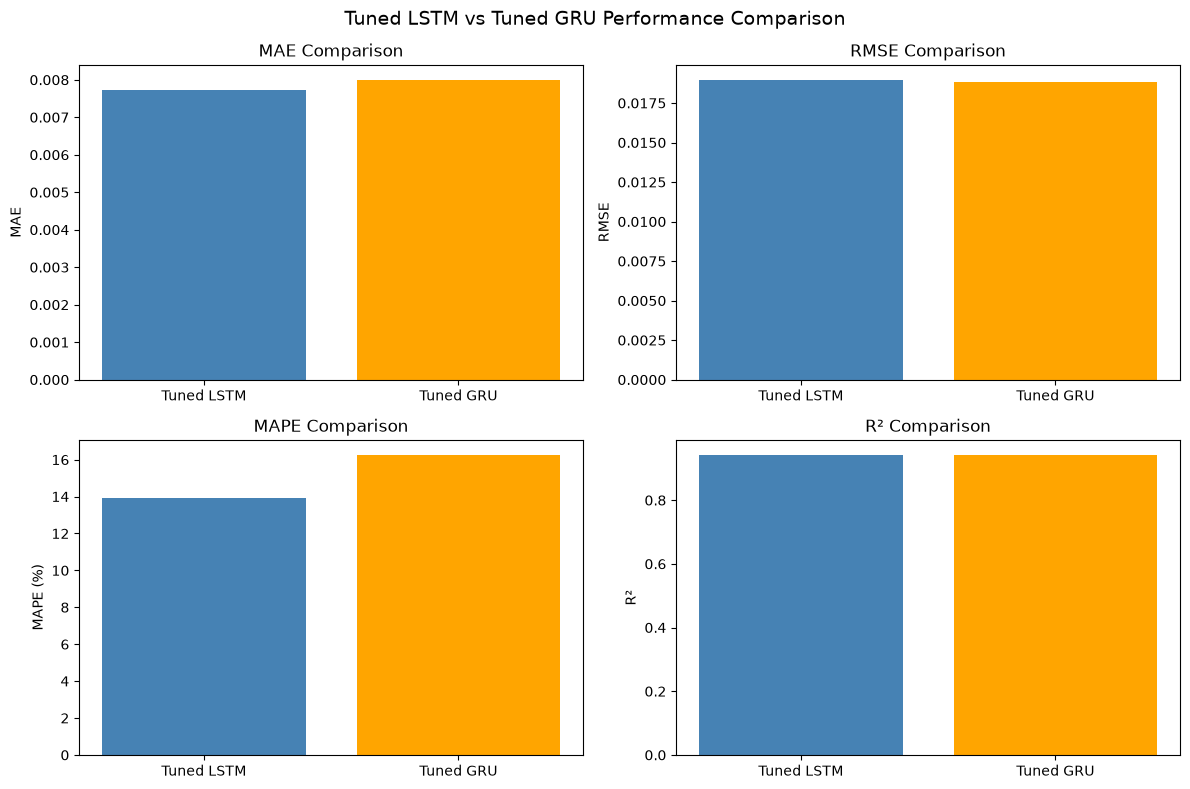

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = ["Tuned LSTM", "Tuned GRU"]

# MAE
axes[0, 0].bar(
    models,
    [0.007717, 0.008001],
    color=["steelblue", "orange"]
)
axes[0, 0].set_title("MAE Comparison")
axes[0, 0].set_ylabel("MAE")

# RMSE
axes[0, 1].bar(
    models,
    [0.018971, 0.018833],
    color=["steelblue", "orange"]
)
axes[0, 1].set_title("RMSE Comparison")
axes[0, 1].set_ylabel("RMSE")

# MAPE
axes[1, 0].bar(
    models,
    [13.91, 16.25],
    color=["steelblue", "orange"]
)
axes[1, 0].set_title("MAPE Comparison")
axes[1, 0].set_ylabel("MAPE (%)")

# R²
axes[1, 1].bar(
    models,
    [0.940856, 0.941713],
    color=["steelblue", "orange"]
)
axes[1, 1].set_title("R² Comparison")
axes[1, 1].set_ylabel("R²")

plt.suptitle(
    "Tuned LSTM vs Tuned GRU Performance Comparison",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/dl_model_comparison.png",
    bbox_inches="tight"
)

plt.show()

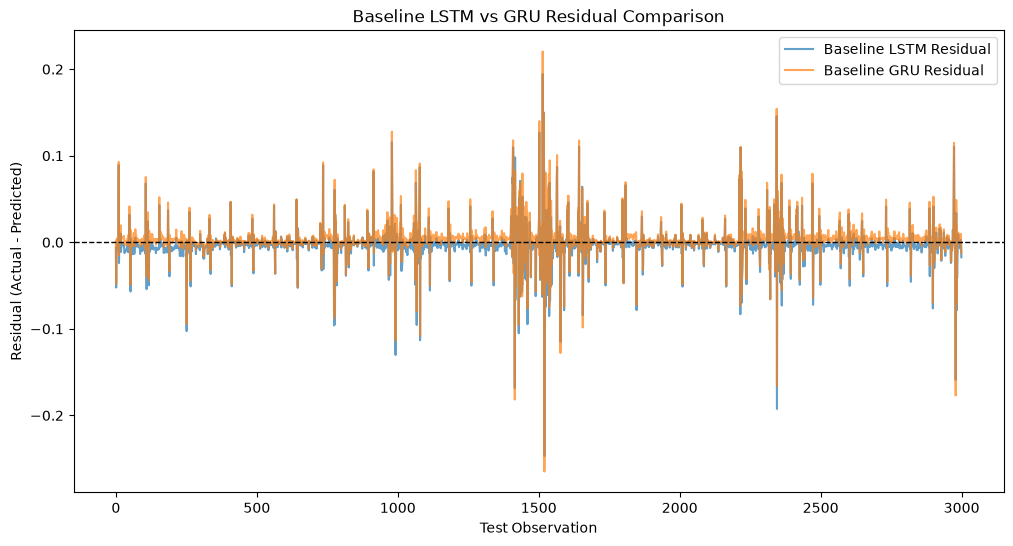

In [22]:
plt.figure(figsize=(12, 6))

sample_size = 3000

plt.plot(
    lstm_residuals[:sample_size],
    label="Baseline LSTM Residual",
    alpha=0.7
)

plt.plot(
    gru_residuals[:sample_size],
    label="Baseline GRU Residual",
    alpha=0.7
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Baseline LSTM vs GRU Residual Comparison"
)

plt.xlabel("Test Observation")
plt.ylabel("Residual (Actual - Predicted)")

plt.legend()

plt.savefig(
    "../reports/figures/dl_residual_comparison.png",
    bbox_inches="tight"
)

plt.show()

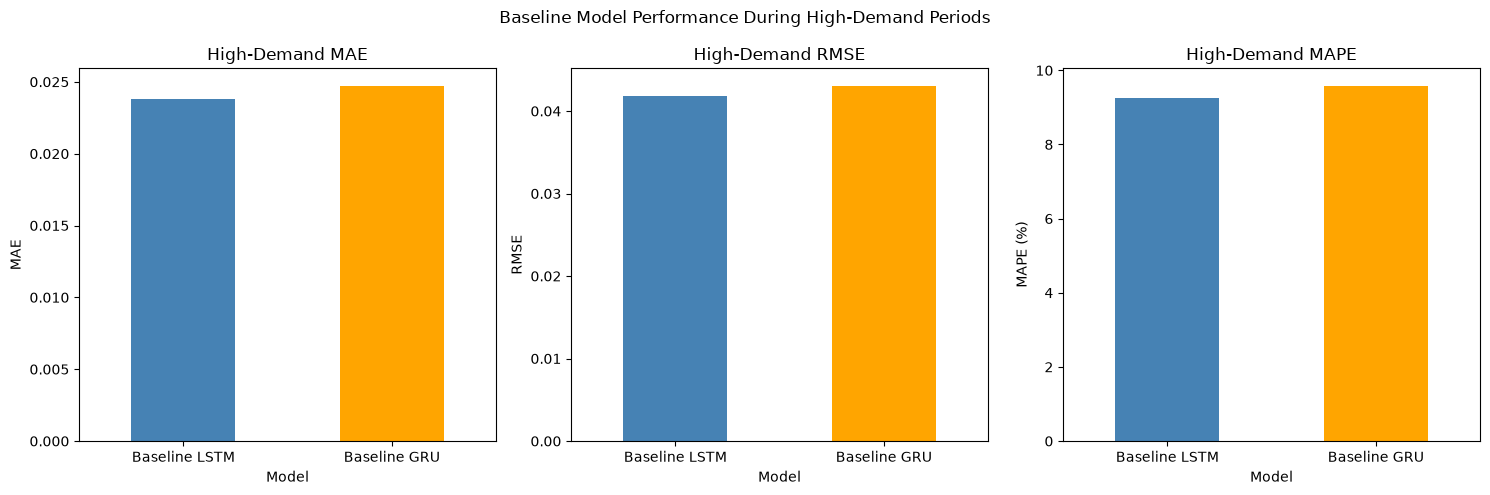

In [23]:
high_plot_df = high_demand_df.set_index("Model")[
    ["MAE", "RMSE", "MAPE (%)"]
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["steelblue", "orange"]

high_plot_df["MAE"].plot(
    kind="bar",
    ax=axes[0],
    color=colors
)
axes[0].set_title("High-Demand MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=0)

high_plot_df["RMSE"].plot(
    kind="bar",
    ax=axes[1],
    color=colors
)
axes[1].set_title("High-Demand RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=0)

high_plot_df["MAPE (%)"].plot(
    kind="bar",
    ax=axes[2],
    color=colors
)
axes[2].set_title("High-Demand MAPE")
axes[2].set_ylabel("MAPE (%)")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle(
    "Baseline Model Performance During High-Demand Periods"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/dl_high_demand_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
group3_comparison = pd.read_csv(
    "../reports/member3_model_comparison.csv"
)

group3_comparison

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,0.021266,0.037773,3.058364,0.998078
1,Gradient Boosting,0.157055,0.211374,37.662388,0.939815
2,XGBoost,0.015709,0.028448,2.360030,0.998910


In [25]:
group3_best = group3_comparison.loc[
    group3_comparison["RMSE"].idxmin()
]

group3_best


Model     XGBoost
MAE      0.015709
RMSE     0.028448
MAPE      2.36003
R2        0.99891
Name: 2, dtype: object

In [26]:
xgb_pred = pd.read_csv(
    "../reports/xgboost_test_predictions.csv"
)

print("XGBoost predictions shape:", xgb_pred.shape)
print("Columns:", xgb_pred.columns.tolist())

xgb_pred.head()

XGBoost predictions shape: (307117, 4)
Columns: ['Datetime', 'Actual', 'Predicted', 'Residual']


,Datetime,Actual,Predicted,Residual
0,2010-04-18 17:07:00,0.342,0.340738,0.001262
1,2010-04-18 17:08:00,0.340,0.337095,0.002905
2,2010-04-18 17:09:00,0.340,0.337728,0.002272
3,2010-04-18 17:10:00,0.252,0.244834,0.007166
4,2010-04-18 17:11:00,0.248,0.242174,0.005826


In [27]:
xgb_pred.describe()

,Actual,Predicted,Residual
count,307117.000000,307117.000000,307117.000000
mean,0.958121,0.957706,0.000416
std,0.861601,0.860038,0.028445
min,0.138000,0.139607,-0.715952
25%,0.320000,0.324722,-0.008057
50%,0.552000,0.546855,0.001176
75%,1.432000,1.427409,0.011469
max,9.724000,9.663181,0.267233


In [28]:
print("First XGBoost timestamp:", xgb_pred["Datetime"].iloc[0])
print("Last XGBoost timestamp :", xgb_pred["Datetime"].iloc[-1])

print("Number of XGBoost predictions:", len(xgb_pred))
print("Number of DL predictions     :", len(lstm_pred))

First XGBoost timestamp: 2010-04-18 17:07:00
Last XGBoost timestamp : 2010-11-26 21:02:00
Number of XGBoost predictions: 307117
Number of DL predictions     : 307058


## Comparison with Group 3 Best Non-DL Model

Group 3 evaluated Random Forest, Gradient Boosting, and XGBoost using a
chronological held-out test period.

XGBoost was selected as the best-performing non-deep-learning model with:

- MAE: 0.01571
- RMSE: 0.02845
- MAPE: 2.36%
- R²: 0.99891

The XGBoost prediction artifact contains 307,117 predictions covering
approximately the same final chronological test period used by the deep
learning pipeline.

However, an important evaluation-scale difference was identified during
Member 3 verification.

The XGBoost prediction artifact contains Global_active_power values in
their original units, whereas the currently exported LSTM and GRU
prediction artifacts contain scaled target values produced by the
MinMax-scaled deep-learning pipeline.

Therefore, MAE and RMSE values from the existing DL artifacts cannot be
directly compared numerically with XGBoost MAE and RMSE until the DL
predictions are inverse-transformed to the original target scale.

This limitation is recorded to avoid presenting a misleading direct
comparison between metrics calculated on different target scales.

In [30]:
final_dl_selection = pd.DataFrame({
    "Selected_Model": ["Tuned LSTM"],
    "Architecture": ["LSTM"],
    "Units": [128],
    "Dropout": [0.30],
    "Window_Size": [60],
    "Batch_Size": [64],
    "Optimizer": ["Adam"],
    "Epochs": [3],
    "MAE": [0.007717],
    "RMSE": [0.018971],
    "MAPE": [13.91],
    "R2": [0.940856]
})

final_dl_selection.to_csv(
    "../reports/final_dl_selection.csv",
    index=False
)

final_dl_selection

,Selected_Model,Architecture,Units,Dropout,Window_Size,Batch_Size,Optimizer,Epochs,MAE,RMSE,MAPE,R2
0,Tuned LSTM,LSTM,128,0.3,60,64,Adam,3,0.007717,0.018971,13.91,0.940856


In [33]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# --------------------------------------------------
# FINAL MODEL PREPROCESSING
# --------------------------------------------------

DATA_PATH = "../data/processed/feature_engineered_dataset.csv"

TARGET = "Global_active_power"

FEATURES = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "Week",
    "Quarter",
    "Weekend",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "RollingMean_24",
    "RollingStd_24",
    "Difference",
    "PctChange"
]

WINDOW_SIZE = 60
BATCH_SIZE = 64

# Load dataset
final_df = pd.read_csv(DATA_PATH)

# Parse and sort chronologically
final_df["Datetime"] = pd.to_datetime(final_df["Datetime"])
final_df = final_df.sort_values("Datetime").reset_index(drop=True)

# Select exactly the same features + target
final_data = final_df[FEATURES + [TARGET]].copy()

# Chronological 70 / 15 / 15 split
train_size = int(len(final_data) * 0.70)
val_size = int(len(final_data) * 0.15)

final_train_df = final_data.iloc[:train_size]
final_val_df = final_data.iloc[
    train_size:train_size + val_size
]
final_test_df = final_data.iloc[
    train_size + val_size:
]

# IMPORTANT:
# Fit scaler ONLY on training data
final_scaler = MinMaxScaler()

final_train_scaled = final_scaler.fit_transform(
    final_train_df
)

final_val_scaled = final_scaler.transform(
    final_val_df
)

final_test_scaled = final_scaler.transform(
    final_test_df
)

# Memory-efficient time-series generators
final_train_generator = TimeseriesGenerator(
    final_train_scaled[:, :-1],
    final_train_scaled[:, -1],
    length=WINDOW_SIZE,
    batch_size=BATCH_SIZE
)

final_val_generator = TimeseriesGenerator(
    final_val_scaled[:, :-1],
    final_val_scaled[:, -1],
    length=WINDOW_SIZE,
    batch_size=BATCH_SIZE
)

final_test_generator = TimeseriesGenerator(
    final_test_scaled[:, :-1],
    final_test_scaled[:, -1],
    length=WINDOW_SIZE,
    batch_size=BATCH_SIZE
)

print("FINAL PREPROCESSING READY")
print("=" * 45)

print("Dataset:", final_df.shape)
print("Model data:", final_data.shape)

print("\nChronological period:")
print("Start:", final_df["Datetime"].min())
print("End  :", final_df["Datetime"].max())

print("\nSplits:")
print("Train      :", final_train_df.shape)
print("Validation :", final_val_df.shape)
print("Test       :", final_test_df.shape)

print("\nConfiguration:")
print("Features    :", len(FEATURES))
print("Window size :", WINDOW_SIZE)
print("Batch size  :", BATCH_SIZE)

print("\nGenerator batches:")
print("Train      :", len(final_train_generator))
print("Validation :", len(final_val_generator))
print("Test       :", len(final_test_generator))

print(
    "\nExpected test predictions:",
    len(final_test_df) - WINDOW_SIZE
)

FINAL PREPROCESSING READY
Dataset: (2047446, 26)
Model data: (2047446, 21)

Chronological period:
Start: 2006-12-16 20:12:00
End  : 2010-11-26 21:02:00

Splits:
Train      : (1433212, 21)
Validation : (307116, 21)
Test       : (307118, 21)

Configuration:
Features    : 20
Window size : 60
Batch size  : 64

Generator batches:
Train      : 22393
Validation : 4798
Test       : 4798

Expected test predictions: 307058


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
import tensorflow as tf
import numpy as np
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Final selected DL architecture
final_model = Sequential([
    Input(shape=(WINDOW_SIZE, len(FEATURES))),
    LSTM(128),
    Dropout(0.30),
    Dense(1)
])

final_model.compile(
    optimizer="adam",
    loss="mse"
)

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,417 (298.50 KB)

 Trainable params: 76,417 (298.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Automatically save the best validation model
final_checkpoint = ModelCheckpoint(
    "../models/final_dl_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train selected Tuned LSTM
final_history = final_model.fit(
    final_train_generator,
    validation_data=final_val_generator,
    epochs=3,
    callbacks=[
        final_early_stopping,
        final_checkpoint
    ],
    verbose=1
)

Epoch 1/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 8.2978e-04
Epoch 1: val_loss improved from None to 0.00048, saving model to ../models/final_dl_model.keras

Epoch 1: finished saving model to ../models/final_dl_model.keras
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2834s 126ms/step - loss: 8.2978e-04 - val_loss: 4.8310e-04
Epoch 2/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 6.0921e-04
Epoch 2: val_loss improved from 0.00048 to 0.00046, saving model to ../models/final_dl_model.keras

Epoch 2: finished saving model to ../models/final_dl_model.keras
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2673s 119ms/step - loss: 6.0921e-04 - val_loss: 4.6301e-04
Epoch 3/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 5.8789e-04
Epoch 3: val_loss improved from 0.00046 to 0.00045, saving model to ../models/final_dl_model.keras

Epoch 3: finished saving model to ../models/final_dl_model.keras
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2659s 119ms/step - loss: 5.8789e-04 - val_loss: 4.4528e-04
Rest

In [36]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# --------------------------------------------------
# LOAD FINAL SELECTED MODEL
# --------------------------------------------------

best_final_model = load_model(
    "../models/final_dl_model.keras"
)

print("Final DL model loaded successfully.")

# --------------------------------------------------
# GENERATE TEST PREDICTIONS
# --------------------------------------------------

final_pred_scaled = best_final_model.predict(
    final_test_generator,
    verbose=1
).flatten()

# Actual scaled target values corresponding to predictions
final_actual_scaled = final_test_scaled[
    WINDOW_SIZE:,
    -1
]

print("\nPrediction count:", len(final_pred_scaled))
print("Actual count    :", len(final_actual_scaled))

# --------------------------------------------------
# CONVERT TARGET BACK TO ORIGINAL GLOBAL ACTIVE POWER
# --------------------------------------------------

# Target is the final column used by final_scaler
target_scale = final_scaler.scale_[-1]
target_min = final_scaler.min_[-1]

final_pred_original = (
    final_pred_scaled - target_min
) / target_scale

final_actual_original = (
    final_actual_scaled - target_min
) / target_scale

# --------------------------------------------------
# ORIGINAL-UNIT METRICS
# --------------------------------------------------

final_mae = mean_absolute_error(
    final_actual_original,
    final_pred_original
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_actual_original,
        final_pred_original
    )
)

nonzero_mask = final_actual_original != 0

final_mape = np.mean(
    np.abs(
        (
            final_actual_original[nonzero_mask]
            - final_pred_original[nonzero_mask]
        )
        / final_actual_original[nonzero_mask]
    )
) * 100

final_r2 = r2_score(
    final_actual_original,
    final_pred_original
)

print("\nFINAL TUNED LSTM RESULTS")
print("=" * 40)
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("MAPE:", final_mape)
print("R²  :", final_r2)

# --------------------------------------------------
# TIMESTAMPS
# --------------------------------------------------

test_start_index = train_size + val_size

final_timestamps = final_df["Datetime"].iloc[
    test_start_index + WINDOW_SIZE:
].reset_index(drop=True)

# --------------------------------------------------
# SAVE FINAL PREDICTIONS
# --------------------------------------------------

final_predictions_df = pd.DataFrame({
    "Datetime": final_timestamps,
    "Actual": final_actual_original,
    "Predicted": final_pred_original
})

final_predictions_df["Residual"] = (
    final_predictions_df["Actual"]
    - final_predictions_df["Predicted"]
)

final_predictions_df.to_csv(
    "../reports/final_dl_predictions.csv",
    index=False
)

# --------------------------------------------------
# SAVE FINAL METRICS
# --------------------------------------------------

final_metrics_df = pd.DataFrame({
    "Model": ["Final Tuned LSTM"],
    "MAE": [final_mae],
    "RMSE": [final_rmse],
    "MAPE": [final_mape],
    "R2": [final_r2],
    "Window_Size": [WINDOW_SIZE],
    "Batch_Size": [BATCH_SIZE],
    "Units": [128],
    "Dropout": [0.30]
})

final_metrics_df.to_csv(
    "../reports/final_dl_metrics.csv",
    index=False
)

print("\nSaved:")
print("../models/final_dl_model.keras")
print("../reports/final_dl_predictions.csv")
print("../reports/final_dl_metrics.csv")

Final DL model loaded successfully.
4798/4798 ━━━━━━━━━━━━━━━━━━━━ 209s 43ms/step

Prediction count: 307058
Actual count    : 307058

FINAL TUNED LSTM RESULTS
MAE : 0.08646431702620888
RMSE: 0.207163729187524
MAPE: 11.851874216341091
R²  : 0.9421948569362373

Saved:
../models/final_dl_model.keras
../reports/final_dl_predictions.csv
../reports/final_dl_metrics.csv


In [37]:
final_comparison = pd.DataFrame({
    "Model": [
        "Final Tuned LSTM",
        "XGBoost"
    ],
    "Model_Type": [
        "Deep Learning",
        "Non-Deep Learning"
    ],
    "MAE": [
        final_mae,
        0.01571
    ],
    "RMSE": [
        final_rmse,
        0.02845
    ],
    "MAPE": [
        final_mape,
        2.36
    ],
    "R2": [
        final_r2,
        0.99891
    ]
})

final_comparison.to_csv(
    "../reports/final_dl_vs_xgboost.csv",
    index=False
)

final_comparison

,Model,Model_Type,MAE,RMSE,MAPE,R2
0,Final Tuned LSTM,Deep Learning,0.086464,0.207164,11.851874,0.942195
1,XGBoost,Non-Deep Learning,0.015710,0.028450,2.360000,0.998910


# Final Member 3 Findings

## Final Deep Learning Model

After evaluating the LSTM and GRU experiments, the Tuned LSTM was selected
as the preferred deep-learning configuration.

Configuration:

- Model: LSTM
- Hidden units: 128
- Dropout: 0.30
- Sequence window: 60
- Batch size: 64
- Optimizer: Adam
- Epochs: 3
- Early Stopping: Applied

The selected configuration was reproduced and the best validation checkpoint
was saved as:

`models/final_dl_model.keras`

## Final Reproduced LSTM Performance

Evaluation after converting predictions back to the original
Global_active_power scale produced:

- MAE: 0.086464
- RMSE: 0.207164
- MAPE: 11.8519%
- R²: 0.942195

Final prediction outputs were saved to:

`reports/final_dl_predictions.csv`

Final metrics were saved to:

`reports/final_dl_metrics.csv`

## Comparison With Group 3 Best Non-DL Model

Group 3 selected XGBoost as its best non-deep-learning forecasting model.

XGBoost achieved:

- MAE: 0.015710
- RMSE: 0.028450
- MAPE: 2.36%
- R²: 0.998910

After evaluating both models on the original target scale, XGBoost achieved
lower MAE, RMSE and MAPE and a higher R² than the final Tuned LSTM.

Therefore:

- Best Deep Learning Model: Tuned LSTM
- Best Overall Model in the DL vs Group 3 comparison: XGBoost

## Artifact Verification

During Member 3 validation, it was identified that the originally exported
LSTM and GRU model files and prediction CSV files represented their baseline
configurations, although tuned configurations had also been trained and
evaluated.

The selected Tuned LSTM was therefore reproduced during final integration.
The best validation checkpoint was exported correctly as:

`models/final_dl_model.keras`

This resolved the final deep-learning model artifact inconsistency.

## Final Conclusion

The deep-learning evaluation stage successfully verified the chronological
Train/Validation/Test setup, checked scaling-related data leakage, reviewed
overfitting behaviour, managed model experiments, compared LSTM and GRU
performance, performed residual and high-demand analysis, created comparison
tables and visualisations, selected the final deep-learning configuration,
and compared the selected DL model with Group 3's best non-DL model.

The Tuned LSTM was selected as the final deep-learning model, while XGBoost
demonstrated the strongest overall forecasting performance.